# Team 5 — Modeling & Evaluation
**Author: MaCoi Hollins** | Predicting customer churn (IBM Telco dataset)

This notebook builds, tunes, and compares four classifiers, then evaluates them
using accuracy, precision, sensitivity (recall), F1, and ROC/AUC.

> **Note:** The cleaning block below mirrors Samer's preprocessing so this notebook
> runs on its own. In the combined team notebook, replace it with Samer's `df_cleaned`.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## 1. Load the cleaned data (mirrors Samer's preprocessing)
Loads the data, drops the ID column, fixes `TotalCharges`, turns `Churn` into 1/0,
and one-hot encodes the categorical columns.

In [2]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df = df.drop(columns=['customerID'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)
df = df.astype({c: int for c in df.select_dtypes('bool').columns})
print(df.shape)
df.head()

(7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


## 2. Split into features (X) and target (y)
**X** = everything we know about a customer. **y** = the answer we predict (did they churn).

In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']
print('Churn rate:', round(y.mean(), 3))   # ~0.265 -> imbalanced

Churn rate: 0.265


## 3. Stratified train/test split
70% practice pile, 30% quiz pile. `stratify=y` keeps the same ~1-in-4 churn mix in both piles.
`random_state=42` makes the split reproducible.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (4930, 30)  Test: (2113, 30)


## 4. Scale the features (fit on TRAIN only)
KNN measures distance, so features must share one ruler or `TotalCharges` (up to ~8700)
drowns out `tenure` (0–72). We learn the ruler from the training pile only, then apply it
to the test pile — fitting on all data would leak test info and inflate scores.

In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

## 5. Build and tune KNN (our anchor model)
KNN guesses a customer's outcome by looking at its *k* nearest look-alikes.
`GridSearchCV` tries many *k* values (and two weighting schemes) with 5-fold cross-validation
and keeps the best by AUC.

In [6]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={'n_neighbors': list(range(1, 32, 2)), 'weights': ['uniform', 'distance']},
    scoring='roc_auc', cv=5, n_jobs=-1)
knn_grid.fit(X_train_s, y_train)
best_knn = knn_grid.best_estimator_
print('Best KNN params:', knn_grid.best_params_)

Best KNN params: {'n_neighbors': 31, 'weights': 'uniform'}


## 6. Comparison models
Three other classifiers judged on the exact same data, so the comparison is fair.

In [7]:
models = {
    'KNN': best_knn,
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
}

## 7. Evaluate everyone on the same test set
For each model we record accuracy, precision, sensitivity (recall), F1, and AUC.
Because churn is imbalanced, **sensitivity, F1, and AUC matter more than accuracy.**

In [8]:
rows, roc_data = [], {}
for name, m in models.items():
    m.fit(X_train_s, y_train)
    pred  = m.predict(X_test_s)
    proba = m.predict_proba(X_test_s)[:, 1]
    rows.append({'Model': name,
        'Accuracy':    round(accuracy_score(y_test, pred), 3),
        'Precision':   round(precision_score(y_test, pred), 3),
        'Sensitivity': round(recall_score(y_test, pred), 3),
        'F1':          round(f1_score(y_test, pred), 3),
        'AUC':         round(roc_auc_score(y_test, proba), 3)})
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_data[name] = (fpr, tpr, roc_auc_score(y_test, proba))

results = pd.DataFrame(rows).set_index('Model')
results

,Accuracy,Precision,Sensitivity,F1,AUC
Model,,,,,
KNN,0.782,0.591,0.586,0.589,0.821
Logistic Regression,0.809,0.665,0.563,0.610,0.845
Decision Tree,0.732,0.496,0.499,0.497,0.658
Random Forest,0.788,0.630,0.494,0.553,0.819


## 8. Confusion matrix for the winning model
Flipped to the course convention: **rows = predicted, columns = actual**
(sklearn's default is the opposite).

In [9]:
winner = results['AUC'].idxmax()
wpred = models[winner].predict(X_test_s)
cm = confusion_matrix(y_test, wpred).T   # .T flips to course convention
print('Winner by AUC:', winner)
pd.DataFrame(cm, index=['Pred 0', 'Pred 1'], columns=['Actual 0', 'Actual 1'])

Winner by AUC: Logistic Regression


,Actual 0,Actual 1
Pred 0,1393,245
Pred 1,159,316


## 9. ROC curves (all models on one chart)
A higher/left-hugging curve = better. The diagonal is random guessing.

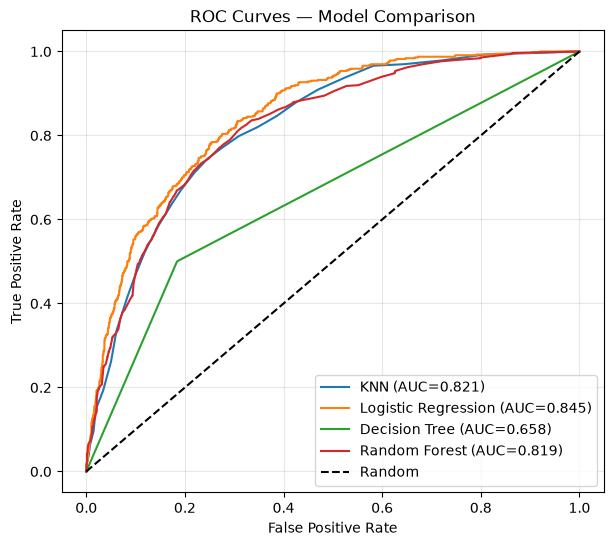

In [10]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 10. Interpretation & final model choice
Overall, logistic regression achieved the strongest performance, with the highest AUC and F1 score among the four models. KNN and random forest followed closely behind and produced similar results, while the decision tree performed noticeably worse than the other approaches. Because only about one-quarter of the customers in the dataset churned, we focused on metrics such as AUC, F1 score, and sensitivity instead of relying only on accuracy. These metrics provided a more meaningful evaluation of each model's ability to identify customers who were likely to churn.
We selected logistic regression as our final model because it performed the best overall across the evaluation metrics. It had the highest AUC and F1 score, which are especially important for an imbalanced dataset where relatively few customers churn. While KNN identified slightly more customers who churned, the difference in sensitivity was very small. Logistic regression also produced the most reliable overall predictions and is easier to interpret, making it a practical choice for explaining the results to business stakeholders.

**AI disclosure:** AI was used to improve the organization and clarity of the writing. All interpretations of the results, model selection decisions, and final conclusions were completed in my own words.
